# Mass-spring-damper benchmark: adaptive delayed-acceptance MCMC vs. baselines

A mass-spring-damper released from rest, `m x'' + c x' + k x = 0`. Mass is fixed; the
unknowns are stiffness `k` and damping `c`, inferred from a noisy observed trajectory.

**Four inference strategies** (the comparison harness lives in
`gp_active_mcmc.verification`; only the physics/problem setup is specific to this
example, in `msd.py`/`msd_methods.py`):

1. **HF-only Metropolis-Hastings** -- ground-truth reference; every step calls the
   expensive high-fidelity (HF) forward model.
2. **Pretrained** -- a POD-GP surrogate trained offline via greedy max-variance active
   learning, then frozen and used as if exact (the "Pretrained Model" arm in Riccius
   et al., 2025).
3. **Riccius-style online active learning** (`online_active`) -- the surrogate is
   substituted for the likelihood and refined online via an uncertainty threshold,
   with no delayed-acceptance (DA) correction.
4. **Adaptive DA** (`adaptive_da`, ours) -- the surrogate is refined online during an
   adaptive phase, guided by the MCMC path; once its accuracy stabilizes it is frozen
   and a delayed-acceptance chain generates the production samples, which carry the DA
   stationarity guarantee (unlike methods 2 and 3).

**Two comparisons.** Comparing `pretrained`'s frozen, uncorrected posterior directly
against `adaptive_da`'s DA-corrected posterior would only show that DA correction
removes surrogate bias -- true, but not this work's contribution. So the two questions
are kept separate:

- **Training cost**: `adaptive_da`'s online, MCMC-path-guided adaptive phase vs.
  `pretrained`'s offline, global active-learning procedure -- how much HF budget each
  needs to reach a trustworthy surrogate.
- **Posterior accuracy**: `hf_only` vs. `online_active` vs. `adaptive_da` (`pretrained`
  excluded, per above). `online_active` stays in this comparison to show that
  continual online refinement *without* DA correction still doesn't recover the true
  posterior.

**Noise level.** `sigma_obs=0.059`, chosen at a 25% noise-to-signal ratio (mean
per-trajectory RMS amplitude over the prior, post-transient -- see the `nsr25` sweep
tag): looser than the tight-noise (`sigma_obs=0.024`, NSR=10%) sensitivity variant
explored earlier, still tighter than the original default (`sigma_obs=0.1`).
`gamma_threshold=0.0059` (kept at the fixed `0.1 * sigma_obs` ratio used throughout).

All results below are aggregated over 25 independent problem instances, produced by
`run.py --n-seeds 25 --sigma-obs 0.059 --gamma-threshold 0.0059 --tag nsr25`.


### What changed in this rebuild

This notebook is functionally identical to the pre-refactor version: only the import
source and the 4th method's name changed, nothing behavioral.

- `gp_active_mcmc/verification/` now holds every problem-agnostic piece of the
  comparison harness (`run_hf_only`, `run_pretrained`, `run_online_active`,
  `run_adaptive_da`, `run_convergence_driven_comparison`, the
  R-hat-driven multi-chain round loop, and the W2/KL/pooled-summary metrics) --
  extracted from what used to be `examples/toy_problem/msd_methods.py`'s only copy, so
  a second example (`examples/navier_stokes/`) can reuse the exact same, tested code
  instead of duplicating it. `examples/toy_problem/msd_methods.py` is now ~200 lines of
  genuinely MSD-specific glue (`Problem`, `build_problem`, this problem's calibrated
  constants) that imports everything else from `gp_active_mcmc.verification`.
- The 4th method's paper-specific name, `"ours"`, is now `"adaptive_da"` everywhere
  (dict keys, function names, CLI flags) -- adopting the vocabulary this same notebook
  already used in its own prose ("Adaptive DA-MCMC"), not inventing a new one.
- A new cell right after the imports demonstrates both changes directly: it imports
  exclusively from `gp_active_mcmc.verification` (not any locally-redefined logic),
  runs a small live comparison, and checks it against a frozen reference captured
  before this refactor -- see that cell for exactly what is (and isn't) guaranteed to
  be reproducible.


In [ ]:
from __future__ import annotations

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from msd_methods import PARAM_NAMES, RESULTS_DIR, build_problem
from msd_plots import plot_accuracy_boxplots, plot_training_cost_boxplot

FIGURES_DIR = RESULTS_DIR / "figures/"
SWEEP_PATH = RESULTS_DIR / "sweep_convergence_driven.jsonl"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Problem setup

One example problem instance: `theta_true` drawn from the prior, and a noisy
synthetic observation of the resulting trajectory.


theta_true: {'k': 67.32655185893088, 'c': 0.6125947561513535}


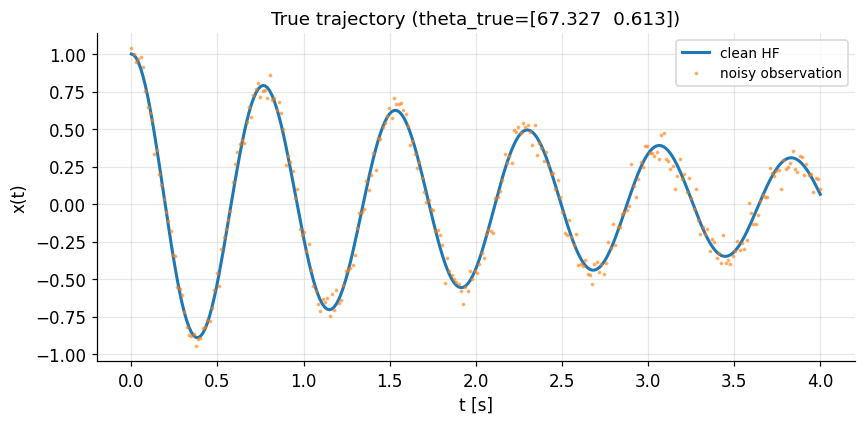

In [ ]:
problem = build_problem(problem_seed=0, sigma_obs=0.059)
print("theta_true:", dict(zip(PARAM_NAMES, problem.theta_true.tolist(), strict=True)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(problem.t, problem.hf_forward(problem.theta_true), lw=2, label="clean HF")
ax.plot(problem.t, problem.y_obs, ".", ms=3, alpha=0.5, label="noisy observation")
ax.set_xlabel("t [s]")
ax.set_ylabel("x(t)")
ax.legend()
ax.set_title(f"True trajectory (theta_true={np.round(problem.theta_true, 3)})")
fig.tight_layout()


## Running the comparison

`run.py --n-seeds 25 --sigma-obs 0.059 --gamma-threshold 0.0059 --tag nsr25` runs both
comparisons above for 25 independent problem instances (fresh `theta_true`/observation
and offline seed design each) and saves per-seed metrics to
`results/sweep_convergence_driven_nsr25.jsonl` and per-seed figures to
`results/figures/nsr25/`. This notebook loads and aggregates that output. (This sweep
was run with `--skip-training-cost`, so the training-cost section below has no data
for it -- that comparison isn't specific to this noise level and doesn't need
re-running per sigma_obs.)


In [ ]:
if not SWEEP_PATH.exists():
    print(f"{SWEEP_PATH} not found -- run `python run.py --n-seeds 25` first.")
    sweep_rows = []
else:
    sweep_rows = [json.loads(line) for line in SWEEP_PATH.read_text().splitlines() if line.strip()]
    print(f"Loaded {len(sweep_rows)} seed(s) from {SWEEP_PATH}")


## Example: surrogate fit and posterior (seed 0)

One example from the sweep: the trained surrogate's prediction at `theta_true` for
each method (top), and the pooled posterior for `hf_only`/`online_active`/`adaptive_da`
(bottom) -- plus `online_active_synced` in both, if this sweep was run with
`--include-synced` (a Riccius-style variant whose replicates pool every
individually-collected HF point into a shared surrogate each round, still without
delayed-acceptance correction -- see
`gp_active_mcmc.verification.methods._make_online_active_sync_hook`).
The same figures are saved for every seed in `results/figures/`.


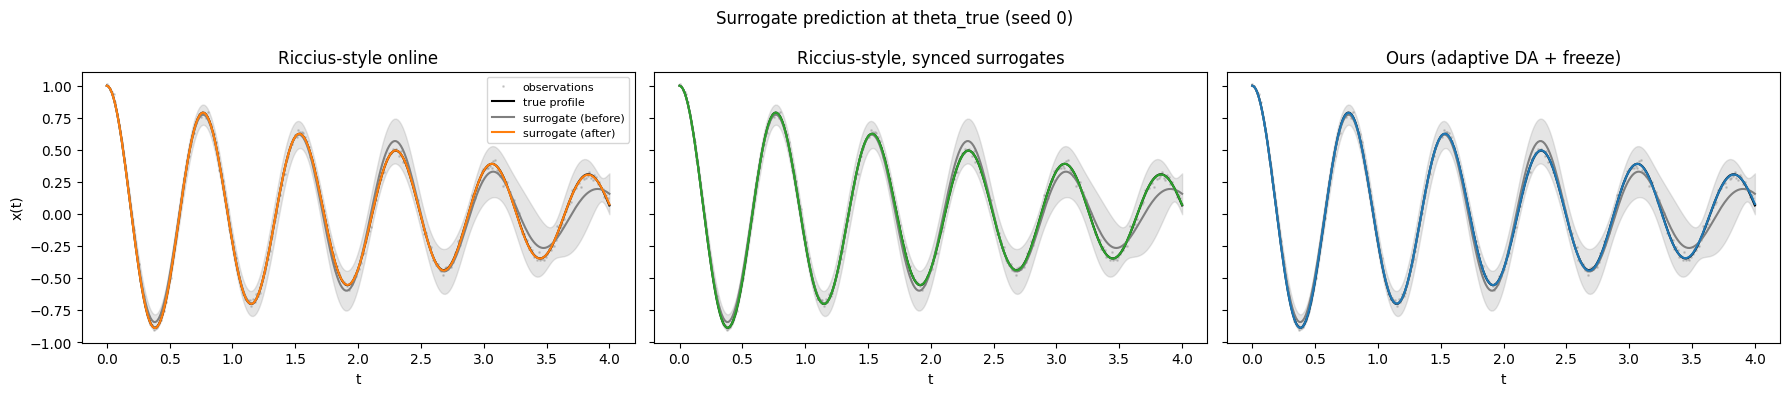

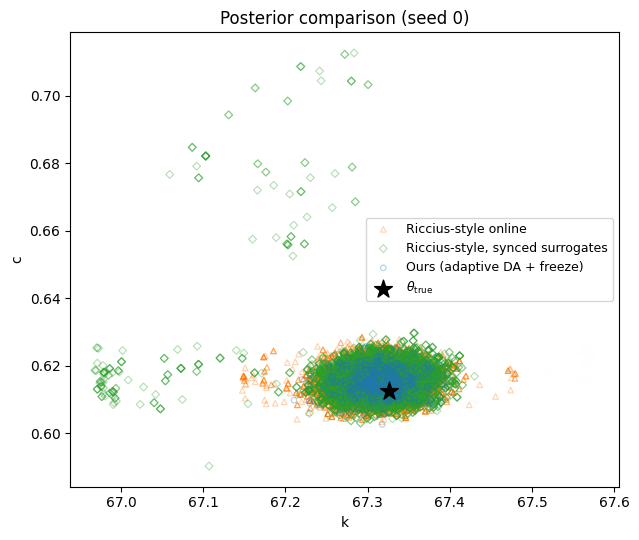

In [ ]:
example_seed = sweep_rows[0]["seed"] if sweep_rows else 0
display(Image(filename=str(FIGURES_DIR / f"surrogate_comparison_seed_{example_seed}.png")))
display(Image(filename=str(FIGURES_DIR / f"posterior_scatter_seed_{example_seed}.png")))


## Training-cost comparison

Extra HF evaluations beyond the shared offline seed design -- `adaptive_da`'s online
adaptive phase vs. `pretrained`'s offline active-learning procedure -- across all
seeds.


In [ ]:
tc_rows = [r for r in sweep_rows if r["training_cost"] is not None]
if not tc_rows:
    print(
        f"No training-cost data in these {len(sweep_rows)} seed(s) -- this sweep was run with "
        "--skip-training-cost. Rerun without that flag to populate this section."
    )
else:
    if len(tc_rows) < len(sweep_rows):
        print(f"Note: only {len(tc_rows)}/{len(sweep_rows)} seed(s) have training-cost data; the rest were "
              "presumably run with --skip-training-cost and are excluded below.")

    tc_df = pd.DataFrame([
        {
            "seed": r["seed"],
            "offline_extra_hf": r["training_cost"]["offline"]["n_hf_extra"],
            "online_extra_hf": r["training_cost"]["online"]["n_hf_extra"],
            "online_converged": r["training_cost"]["online"]["converged"],
        }
        for r in tc_rows
    ])
    print(tc_df[["offline_extra_hf", "online_extra_hf"]].agg(["mean", "median", "std"]))
    print(f"\nadaptive_da's adaptive-phase convergence rate: {tc_df['online_converged'].mean():.1%}")

    fig = plot_training_cost_boxplot(
        tc_df["offline_extra_hf"].to_numpy(), tc_df["online_extra_hf"].to_numpy(), n_init=tc_rows[0]["n_init"]
    )
    fig.savefig(FIGURES_DIR / "training_cost_sweep.png", bbox_inches="tight")


No training-cost data in these 3 seed(s) -- this sweep was run with --skip-training-cost. Rerun without that flag to populate this section.


## Posterior-accuracy comparison

Cost to reach R-hat<=1.01 across 5 replicate chains, and distributional distance
(Wasserstein-2, KL) to the `hf_only` reference posterior, across all seeds.


method
hf_only                 1.0
online_active           1.0
online_active_synced    1.0
Name: convergence_rate, dtype: float64

                     total_coarse_evals                         n_hf_calls  \
                                   mean  median          std          mean   
method                                                                       
hf_only                     2966.666667  3000.0   850.490055  14838.333333   
online_active               2600.000000  2200.0  1153.256259    330.000000   
online_active_synced        2633.333333  2400.0   585.946528    321.333333   

                                              w2_ref                      \
                       median          std      mean    median       std   
method                                                                     
hf_only               15005.0  4252.450274       NaN       NaN       NaN   
online_active           322.0    24.979992  0.003812  0.005121  0.002562   
online_active_synced

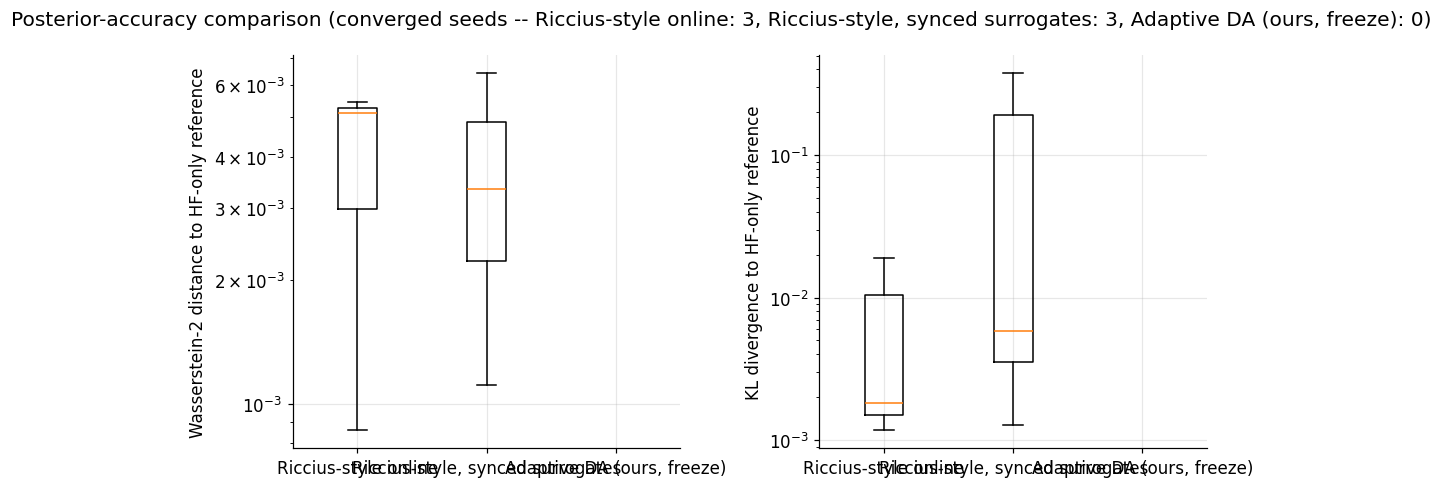

In [ ]:
candidate_methods = ("hf_only", "online_active", "online_active_synced", "adaptive_da")

pa_rows = []
for r in sweep_rows:
    for method in candidate_methods:
        p = r["posterior"].get(method)
        if p is None:
            continue  # e.g. online_active_synced absent from rows run without --include-synced
        pooled = p.get("pooled", {})
        pa_rows.append({
            "seed": r["seed"],
            "method": method,
            "converged": p["converged"],
            "total_coarse_evals": p["total_coarse_evals"],
            "n_hf_calls": pooled.get("n_hf_calls"),
            "w2_ref": pooled.get("wasserstein2_to_reference"),
            "kl_ref": pooled.get("kl_to_reference"),
            "rmse": pooled.get("rmse_to_truth"),
        })
pa_df = pd.DataFrame(pa_rows)
print(pa_df.groupby("method")["converged"].mean().rename("convergence_rate"))
print()
print(pa_df.groupby("method")[["total_coarse_evals", "n_hf_calls", "w2_ref", "kl_ref", "rmse"]].agg(["mean", "median", "std"]))

# Only include online_active_synced in the boxplots if at least one row actually has it
# (mixing seeds run with/without --include-synced would otherwise silently compare
# methods over different, non-overlapping seed sets without saying so).
method_order = ("online_active", "adaptive_da")
if "online_active_synced" in pa_df["method"].unique():
    n_with_synced = pa_df.loc[pa_df["method"] == "online_active_synced", "seed"].nunique()
    n_total = pa_df["seed"].nunique()
    if n_with_synced < n_total:
        print(f"\nNote: online_active_synced present for only {n_with_synced}/{n_total} seeds "
              "(the rest presumably run without --include-synced).")
    method_order = ("online_active", "online_active_synced", "adaptive_da")

converged = pa_df[pa_df["converged"]]
w2_by_method = {m: converged.loc[converged["method"] == m, "w2_ref"].dropna().to_numpy() for m in method_order}
kl_by_method = {m: converged.loc[converged["method"] == m, "kl_ref"].dropna().to_numpy() for m in method_order}

fig = plot_accuracy_boxplots(w2_by_method, kl_by_method, method_order=method_order)
fig.savefig(FIGURES_DIR / "posterior_accuracy_sweep.png", bbox_inches="tight")
